In [1]:
!pip install -q kagglehub tensorflow matplotlib numpy pillow

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from google.colab import files

print("📤 Upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API key set!")

📤 Upload kaggle.json


Saving kaggle.json to kaggle.json
✅ Kaggle API key set!


In [4]:
print("📥 Downloading dataset...")
path = kagglehub.dataset_download("moltean/fruits")
print(f"✅ Dataset path: {path}")

📥 Downloading dataset...
Using Colab cache for faster access to the 'fruits' dataset.
✅ Dataset path: /kaggle/input/fruits


In [5]:
import os

# Dataset downloaded to this path
path = "/kaggle/input/fruits"

# Find the correct folder automatically
for root, dirs, files in os.walk(path):
    if "Training" in dirs:
        TRAIN_DIR = os.path.join(root, "Training")
        TEST_DIR  = os.path.join(root, "Test")
        break

NUM_CLASSES = len(os.listdir(TRAIN_DIR))
print(f"📁 Train  : {TRAIN_DIR}")
print(f"📁 Test   : {TEST_DIR}")
print(f"🍎 Classes: {NUM_CLASSES}")

📁 Train  : /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
📁 Test   : /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test
🍎 Classes: 257


In [6]:
IMG_SIZE   = (100, 100)
BATCH_SIZE = 32
EPOCHS     = 10

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', subset='validation'
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)
print("✅ Data ready!")

Found 108144 images belonging to 257 classes.
Found 26927 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.
✅ Data ready!


In [7]:
model = Sequential([
    Conv2D(32,  (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64,  (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 257)            │        66,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,436,353 (13.11 MB)

 Trainable params: 3,436,353 (13.11 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 3

print("🚀 Training started...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

🚀 Training started...
Epoch 1/3
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 793s 233ms/step - accuracy: 0.4965 - loss: 1.8416 - val_accuracy: 0.8415 - val_loss: 0.4824
Epoch 2/3
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 467s 138ms/step - accuracy: 0.7800 - loss: 0.6455 - val_accuracy: 0.8865 - val_loss: 0.3480
Epoch 3/3
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 475s 140ms/step - accuracy: 0.8363 - loss: 0.4690 - val_accuracy: 0.9039 - val_loss: 0.3164


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 154s 109ms/step - accuracy: 0.9307 - loss: 0.7692

✅ Test Accuracy: 93.07%


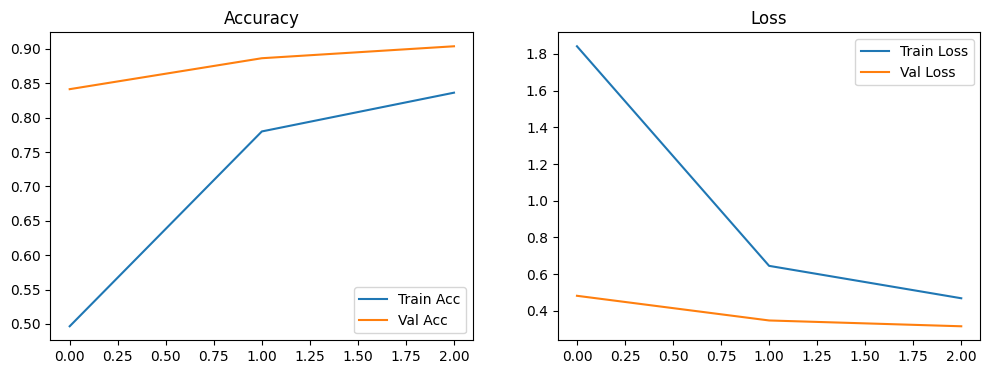

📊 output.png saved!


In [9]:
loss, acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend()

plt.savefig("output.png")
plt.show()
print("📊 output.png saved!")

In [10]:
model.save("fruit_model.keras")
print("💾 fruit_model.keras saved!")

💾 fruit_model.keras saved!


📤 Upload a fruit image:


Saving apple.jpg to apple.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step


/tmp/ipykernel_2420/24859584.py:15: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.savefig("output.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


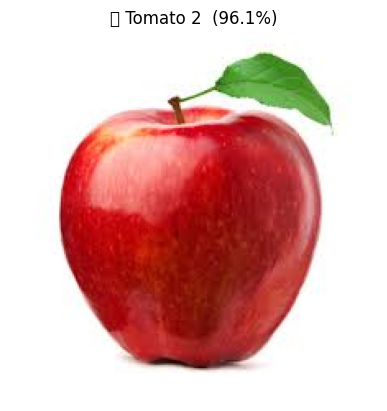

✅ Predicted : Tomato 2
📊 Confidence: 96.1%


In [11]:
from google.colab import files

CLASS_NAMES = list(train_gen.class_indices.keys())

def predict_fruit(image_path):
    img  = load_img(image_path, target_size=IMG_SIZE)
    arr  = np.expand_dims(img_to_array(img) / 255.0, axis=0)
    preds = model.predict(arr)
    label = CLASS_NAMES[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(load_img(image_path))
    plt.title(f"🍎 {label}  ({confidence:.1f}%)")
    plt.axis('off')
    plt.savefig("output.png")
    plt.show()
    print(f"✅ Predicted : {label}")
    print(f"📊 Confidence: {confidence:.1f}%")

print("📤 Upload a fruit image:")
uploaded = files.upload()
for filename in uploaded.keys():
    predict_fruit(filename)

NameError: name 'afed' is not defined